ASSIGNMENT 2 ( DATA INTEGRATION )

Caricamento datasets

In [2]:

import pandas as pd

# ======================
# 1. Matrici GO (gene x go-term)
# ======================

bp = pd.read_csv("gene_go_matrix_propT_rel-is_a-part_of_ont-BP.csv", index_col=0)
cc = pd.read_csv("gene_go_matrix_propT_rel-is_a-part_of_ont-CC.csv", index_col=0)
mf = pd.read_csv("gene_go_matrix_propT_rel-is_a-part_of_ont-MF.csv", index_col=0)

# ======================
# 2. Matrice HPO (gene x hpo-term)
# ======================
hpo = pd.read_csv("gene_hpo_matrix_binary_withAncestors_namespace_Phenotypic abnormality.csv",
                  index_col=0)

# ======================
# 3. Tabelle profondità GO terms
# ======================
depth_bp = pd.read_csv("goterm_depth_propT_rel-is_a-part_of_ont-BP.csv")
depth_cc = pd.read_csv("goterm_depth_propT_rel-is_a-part_of_ont-CC.csv")
depth_mf = pd.read_csv("goterm_depth_propT_rel-is_a-part_of_ont-MF.csv")

# ======================
# Controllo veloce
# ======================
bp.shape, cc.shape, mf.shape, hpo.shape


((5183, 9873), (5183, 1478), (5183, 3258), (5183, 10185))

Visualizzzione distribuzione profondità

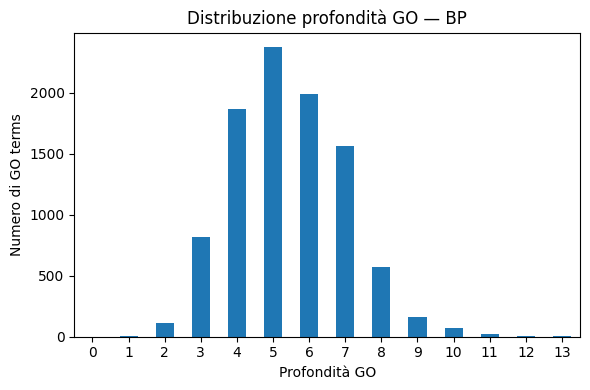

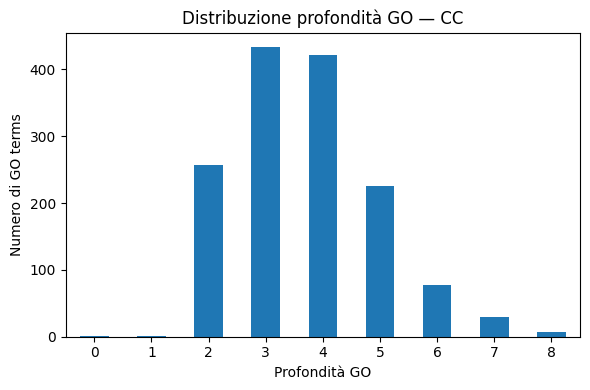

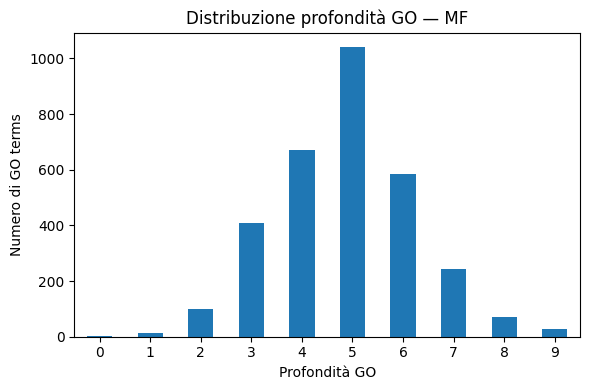

In [ ]:
import matplotlib.pyplot as plt

# Estraggo le profondità come Serie (già coerenti con il tuo codice)
depth_bp_series = depth_bp.iloc[0, 2:].astype(int)
depth_cc_series = depth_cc.iloc[0, 2:].astype(int)
depth_mf_series = depth_mf.iloc[0, 2:].astype(int)


def plot_depth_distribution(depth_series, title):
    depth_counts = depth_series.value_counts().sort_index()

    plt.figure(figsize=(6,4))
    depth_counts.plot(kind="bar")
    plt.xlabel("Profondità GO")
    plt.ylabel("Numero di GO terms")
    plt.title(title)
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()
    #print(depth_counts)  # così vedi anche i numeri a console

# BP
plot_depth_distribution(depth_bp_series, "Distribuzione profondità GO — BP")

# CC
plot_depth_distribution(depth_cc_series, "Distribuzione profondità GO — CC")

# MF
plot_depth_distribution(depth_mf_series, "Distribuzione profondità GO — MF")


Filtraggio dei GO terms con profondità : 3

In [168]:
import pandas as pd

# ======================
# STEP 1 — Scegli la soglia di profondità
# ======================
DEPTH_THRESHOLD = 3   # puoi aumentare a 4 se vuoi solo termini molto specifici
#DEPTH_THRESHOLDS = 4

# ======================
# STEP 2 — Seleziona i GO terms con profondità sufficiente
# ======================

# The depth dataframes have GO terms as column headers (from index 2 onwards)
# and their depths in the first row (index 0) from index 2 onwards.
# We need to extract this information into a Series for easier filtering.

# For depth_bp:
depth_bp_series = depth_bp.iloc[0, 2:].astype(int) # Convert depths to int
valid_bp_terms = depth_bp_series[depth_bp_series >= DEPTH_THRESHOLD].index.tolist()

# For depth_cc:
depth_cc_series = depth_cc.iloc[0, 2:].astype(int) # Convert depths to int
valid_cc_terms = depth_cc_series[depth_cc_series >= DEPTH_THRESHOLD].index.tolist()

# For depth_mf:
depth_mf_series = depth_mf.iloc[0, 2:].astype(int) # Convert depths to int
valid_mf_terms = depth_mf_series[depth_mf_series >= DEPTH_THRESHOLD].index.tolist()


# ======================
# STEP 3 — Filtra le matrici GO sulle colonne valide
# ======================

bp_filtered = bp.loc[:, bp.columns.isin(valid_bp_terms)]
cc_filtered = cc.loc[:, cc.columns.isin(valid_cc_terms)]
mf_filtered = mf.loc[:, mf.columns.isin(valid_mf_terms)]


# ======================
# STEP 4 — Rimuovi eventuali colonne completamente vuote
# ======================

bp_filtered = bp_filtered.loc[:, bp_filtered.sum(axis=0) > 0]
cc_filtered = cc_filtered.loc[:, cc_filtered.sum(axis=0) > 0]
mf_filtered = mf_filtered.loc[:, mf_filtered.sum(axis=0) > 0]


# ======================
# STEP 5 — Output di verifica
# ======================

print("Filtraggio completato:\n")
print(f"BP: {bp.shape[1]} → {bp_filtered.shape[1]} GO terms mantenuti")
print(f"CC: {cc.shape[1]} → {cc_filtered.shape[1]} GO terms mantenuti")
print(f"MF: {mf.shape[1]} → {mf_filtered.shape[1]} GO terms mantenuti")

Filtraggio completato:

BP: 9873 → 9439 GO terms mantenuti
CC: 1478 → 1193 GO terms mantenuti
MF: 3258 → 3042 GO terms mantenuti


DATA INTEGRATION CON MOFA

import mofapy

In [ ]:
pip install  mofax


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.0 MB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 128 kB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.8 MB 2.4 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 3.5 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 53 kB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 113 kB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 2.8 MB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 3.2 MB/s eta 0:00:01
You should consider upgrading via the 

preparazione dati per mofa

In [169]:
import numpy as np

# Intersezione dei geni presenti in tutte le matrici
common_genes = (
    set(bp_filtered.index)
    & set(cc_filtered.index)
    & set(mf_filtered.index)
    & set(hpo.index)
)

common_genes = sorted(common_genes)

print(f"Geni in comune tra tutte le viste: {len(common_genes)}")

# Sottoselezioniamo e riordiniamo le matrici
bp_mofa  = bp_filtered.loc[common_genes]
cc_mofa  = cc_filtered.loc[common_genes]
mf_mofa  = mf_filtered.loc[common_genes]
hpo_mofa = hpo.loc[common_genes]


Geni in comune tra tutte le viste: 5183


Impostazione MOFA

In [170]:
from mofapy2.run.entry_point import entry_point
import pandas as pd

# ============================
# 1. Nomi di views, samples, features
# ============================

view_names = ["BP", "CC", "MF", "HPO"]
groups_names = ["genes"]   # abbiamo una sola group
sample_names = bp_mofa.index.tolist()  # stessi per tutte le viste

features_names = [
    bp_mofa.columns.tolist(),
    cc_mofa.columns.tolist(),
    mf_mofa.columns.tolist(),
    hpo_mofa.columns.tolist()
]

# ============================
# 2. Costruzione della lista "data"
#    struttura: data[view][group] = matrix (samples x features)
# ============================

data = [
    [bp_mofa.values],   # view BP, group "genes"
    [cc_mofa.values],   # view CC
    [mf_mofa.values],   # view MF
    [hpo_mofa.values]   # view HPO
]

likelihoods = ["bernoulli", "bernoulli", "bernoulli", "bernoulli"]

# ============================
# 3. Inizializza entry_point e setta i dati
# ============================

ent = entry_point()

# (opzionale) data options generali
ent.set_data_options(
    scale_views = False,
    scale_groups = False
)

# Qui il passaggio chiave: usare set_data_matrix
ent.set_data_matrix(
    data = data,
    likelihoods = likelihoods,
    views_names = view_names,
    groups_names = groups_names,
    samples_names = [sample_names],   # lista per group
    features_names = features_names   # lista per view
)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Successfully loaded view='BP' group='genes' with N=5183 samples and D=9439 features...
Successfully loaded view='CC' group='genes' with N=5183 samples and D=1193 features...
Successfully loaded view='MF' group='genes' with N=5183 samples and D=3042 features...
Successfully loaded view='HPO' group='genes' with N=5183 samples and D=10185 features...




Impostazione modello e training

In [171]:
# ============================
# MODEL OPTIONS
# ============================

# Tutte le viste sono binarie → bernoulli
likelihoods = ["bernoulli"] * len(view_names)

ent.set_model_options(
    factors = 15,          # puoi portarlo a 15 se vuoi più fattori
    #likelihoods = likelihoods
)

# ============================
# TRAIN OPTIONS
# ============================

ent.set_train_options(
    iter = 500,           # se converge bene puoi aumentare
    convergence_mode = "fast",
    verbose = False,
    seed = 42              # per riproducibilità
)

# ============================
# BUILD + RUN
# ============================

ent.build()
ent.run()


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (BP): bernoulli
- View 1 (CC): bernoulli
- View 2 (MF): bernoulli
- View 3 (HPO): bernoulli




######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -258454611.48 

Iteration 1: time=16.21, ELBO=-133646524.67, deltaELBO=124808086.816 (48.29013733%), Factors=15
Iteration 2: time=15.10, ELBO=-85545127.53, deltaELBO=48101397.142 (18.61115840%), Factors=15
Iteration 3: time=14.36, ELBO=-85432746.38, deltaELBO=112381.142 (0.04348196%), Factors=15
Iteration 4: time=14.27, ELBO=-85414599.98, deltaELBO=18146.408 (0.00702112%), Factors=15
Iteration 5: time=13.98, ELBO=-85401001.37, deltaELBO=13598.609 (0.00526151%), Factors=15
Iteration 6: time=14.02, ELBO=-853

Normalizzazione dei fattori

recupero modello e Z_df

In [174]:
model = ent.model
# 1) Recupera la matrice dei fattori (samples × factors)
Z = model.nodes["Z"].getExpectation()   # shape: n_samples x n_factors

# 2) Costruiamo i nomi dei fattori
n_factors = Z.shape[1]
factor_names = [f"Factor_{i+1}" for i in range(n_factors)]

# 3) sample_names è la lista dei geni che hai usato quando hai chiamato set_data_matrix
Z_df = pd.DataFrame(Z, index=sample_names, columns=factor_names)

Z_df.head()




,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15
10,-1.528164,-0.219360,-0.484415,-0.629754,-0.789675,-0.245350,-0.070914,0.438244,-0.136542,-0.441986,0.265167,0.258670,-0.582551,0.165055,-0.226908
16,1.797280,1.568492,1.285880,2.524589,0.016328,0.287927,0.019602,0.115844,-0.513638,0.519985,-4.455684,0.119780,1.431877,-0.106695,-0.662328
18,-0.093573,0.643556,-0.519884,1.134285,0.142406,-0.591759,-0.086393,0.265990,-0.361446,-0.384800,0.111004,0.329112,-0.195219,-0.160302,-0.669971
19,-0.630183,0.260709,1.130637,0.406203,0.954438,0.043279,-0.103697,1.167427,-0.030682,1.093844,0.274660,0.913916,0.775418,1.342394,-0.320074
20,-0.224720,0.489900,-0.718707,0.549555,0.655517,-0.209147,-0.110507,0.681516,-0.426076,-0.520482,-0.189728,0.387645,0.509050,0.479071,-0.013067


In [175]:
Z_df.shape


(5183, 15)

In [176]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z_df.values)  # stessa forma di Z_df ma scalata

print(Z_scaled)


[[-1.16774155 -0.19517905 -0.50065367 ... -0.61839184  0.16328802
  -0.22503333]
 [ 1.34909994  1.29299421  1.30222208 ...  1.47023654 -0.12004815
  -0.66077824]
 [-0.08198019  0.52309551 -0.53677627 ... -0.21679277 -0.17594085
  -0.66842647]
 ...
 [-1.20742413 -0.29551312 -0.13019709 ... -0.03832999  0.27672688
  -0.29521773]
 [-0.97738517 -0.06352661 -0.59825479 ... -0.58426072  0.05809084
  -0.22346255]
 [-0.66068333  0.09551916  0.04088816 ... -1.09680149 -0.1399512
  -0.46700683]]


matrice di similarità integrata


In [177]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Usa Z_scaled se hai fatto lo scaling, altrimenti Z_df.values
similarity_matrix = cosine_similarity(Z_scaled)

# Trasformiamo in DataFrame con indici/colonne = geni
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=Z_df.index,
    columns=Z_df.index
)

similarity_df.iloc[:5, :5]


,10,16,18,19,20
10,1.000000,-0.537270,0.067727,-0.181525,0.015518
16,-0.537270,1.000000,0.218143,0.163049,0.223054
18,0.067727,0.218143,1.000000,0.015544,0.604291
19,-0.181525,0.163049,0.015544,1.000000,0.332780
20,0.015518,0.223054,0.604291,0.332780,1.000000


Visualizzazione similarità

<Axes: >

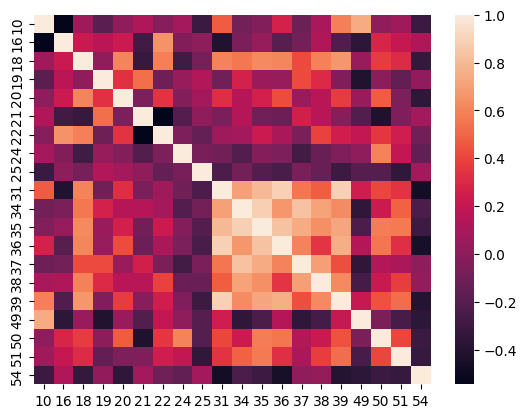

In [178]:
import seaborn as sns
sns.heatmap(similarity_df.iloc[:20, :20])


CLUSTERING

In [179]:
from sklearn.cluster import SpectralClustering

# Z_scaled: matrice (n_geni × n_fattori) che hai usato per la cosine
sc = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
)

labels = sc.fit_predict(Z_scaled)
Z_df["cluster"] = labels
Z_df

#np.unique(labels, return_counts=True)

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15,cluster
10,-1.528164,-0.219360,-0.484415,-0.629754,-0.789675,-0.245350,-0.070914,0.438244,-0.136542,-0.441986,0.265167,0.258670,-0.582551,0.165055,-0.226908,0
16,1.797280,1.568492,1.285880,2.524589,0.016328,0.287927,0.019602,0.115844,-0.513638,0.519985,-4.455684,0.119780,1.431877,-0.106695,-0.662328,0
18,-0.093573,0.643556,-0.519884,1.134285,0.142406,-0.591759,-0.086393,0.265990,-0.361446,-0.384800,0.111004,0.329112,-0.195219,-0.160302,-0.669971,0
19,-0.630183,0.260709,1.130637,0.406203,0.954438,0.043279,-0.103697,1.167427,-0.030682,1.093844,0.274660,0.913916,0.775418,1.342394,-0.320074,0
20,-0.224720,0.489900,-0.718707,0.549555,0.655517,-0.209147,-0.110507,0.681516,-0.426076,-0.520482,-0.189728,0.387645,0.509050,0.479071,-0.013067,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105371045,-0.445358,0.399338,0.865613,-0.411385,-0.476186,0.217040,-0.097974,0.366010,-0.317372,-0.177008,0.394441,0.182332,-0.613813,-0.144486,-0.292844,0
105804841,-0.711215,0.059987,-0.921559,-1.503491,-0.796506,-0.393623,-0.135441,0.512142,-0.178670,-0.152628,0.164787,0.017818,0.155049,0.295285,1.073992,0
109580095,-1.580596,-0.339899,-0.120653,-0.623555,-0.797629,-0.249815,-0.067868,0.481016,-0.205920,-0.647687,0.108054,0.404596,-0.023097,0.273855,-0.297040,0
111365204,-1.276651,-0.061197,-0.580252,-0.823566,-0.835968,0.828288,-0.072778,0.435680,-0.275706,-0.427081,-0.076217,0.236644,-0.549633,0.064159,-0.225338,0


Numero di cluster ottimale

In [180]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

Ks = range(2, 11)   # proviamo k da 2 a 10
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(Z_scaled)
    score = silhouette_score(Z_scaled, labels_k)
    sil_scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

best_k = Ks[int(np.argmax(sil_scores))]
print("k scelto (massimo silhouette):", best_k)


k=2, silhouette=0.3331
k=3, silhouette=0.3357
k=4, silhouette=0.1388
k=5, silhouette=0.1357
k=6, silhouette=0.1400
k=7, silhouette=0.1653
k=8, silhouette=0.1792
k=9, silhouette=0.1695
k=10, silhouette=0.1903
k scelto (massimo silhouette): 3


Spectral with optimal k

Pulisco la Z_df

In [182]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# 1) Partiamo da Z_df originale (senza cluster dentro)
Z_clean = Z_df.copy()

# Se hai già aggiunto la colonna 'cluster', rimuovila per sicurezza:
if "cluster" in Z_clean.columns:
    Z_clean = Z_clean.drop(columns=["cluster"])

# 2) Rimuovi i fattori con varianza zero (colonne costanti)
var_factors = Z_clean.var()
Z_clean = Z_clean.loc[:, var_factors > 0]

print("Fattori usati:", Z_clean.shape[1])

# 3) Rimuovi eventuali geni (righe) che hanno NaN nei fattori
Z_clean = Z_clean.dropna(axis=0)
print("Geni rimasti dopo dropna:", Z_clean.shape[0])

# 4) Standardizzazione
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z_clean.values)

# 5) Ricostruzione della similarity (cosine)
similarity_matrix = cosine_similarity(Z_scaled)

sim = pd.DataFrame(
    similarity_matrix,
    index=Z_clean.index,
    columns=Z_clean.index
)

# 6) Controllo finale sui NaN
print("NaN nella similarity:", sim.isna().sum().sum())


Fattori usati: 15
Geni rimasti dopo dropna: 5183
NaN nella similarity: 0


In [183]:
import numpy as np

print("NaN totali in sim:", sim.isna().sum().sum())

# Vedi quali geni hanno almeno un NaN nella riga/colonna
mask_nan_rows = sim.isna().any(axis=1)   # True = riga con almeno un NaN
genes_with_nan = sim.index[mask_nan_rows]

print("Numero di geni con almeno un NaN:", mask_nan_rows.sum())
print("Primi geni con NaN:", genes_with_nan[:10].tolist())


NaN totali in sim: 0
Numero di geni con almeno un NaN: 0
Primi geni con NaN: []


In [184]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(
    n_clusters=best_k,
    affinity='nearest_neighbors',  # costruisce lui la matrice di affinità
    n_neighbors=10,                # puoi variare (5–20)
    random_state=42
)

labels = sc.fit_predict(Z_scaled)

Z_clean["cluster"] = labels

# Distribuzione dei geni per cluster
unique, counts = np.unique(labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"Cluster {c}: {n} geni")



Cluster 0: 5136 geni
Cluster 1: 29 geni
Cluster 2: 18 geni


In [185]:
# Restrizione a geni usati in Z_clean
sim_for_plot = sim.loc[Z_clean.index, Z_clean.index]

# Ordine secondo i cluster
order = np.argsort(Z_clean["cluster"].values)
genes_ordered = sim_for_plot.index[order]

sim_ordered = sim_for_plot.loc[genes_ordered, genes_ordered]


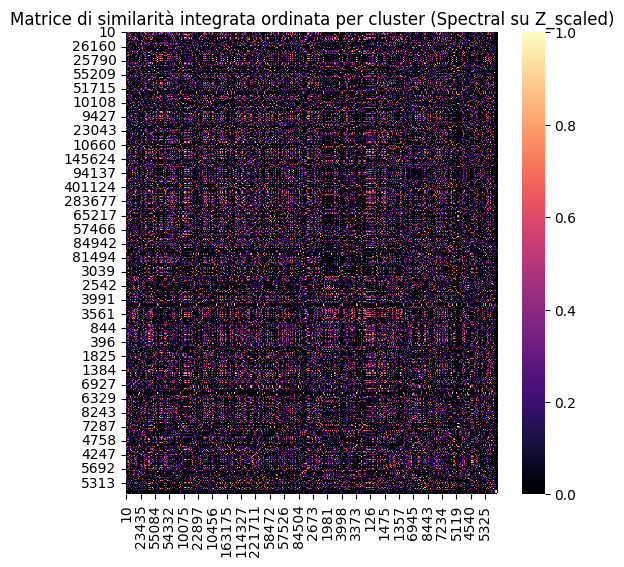

In [186]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(sim_ordered, cmap="magma", vmin=0, vmax=1)
plt.title("Matrice di similarità integrata ordinata per cluster (Spectral su Z_scaled)")
plt.show()


In [187]:
pip install umap-learn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


UMAP

In [188]:
import umap
import numpy as np
import pandas as pd

# UMAP con parametri standard per dati continui
reducer = umap.UMAP(
    n_neighbors=15,         # quanto guardi “in locale”
    min_dist=0.1,           # quanto compatti i cluster
    metric='euclidean',
    random_state=42
)

umap_coords = reducer.fit_transform(Z_scaled)

# Costruiamo un DataFrame per comodo
UMAP_df = pd.DataFrame({
    "UMAP1": umap_coords[:,0],
    "UMAP2": umap_coords[:,1],
    "cluster": Z_clean["cluster"].values
}, index=Z_clean.index)

UMAP_df


,UMAP1,UMAP2,cluster
10,5.373604,6.273725,0
16,10.070495,-0.342112,0
18,7.729909,1.876693,0
19,4.529934,3.095731,0
20,7.971571,2.241178,0
...,...,...,...
105371045,4.036974,3.645935,0
105804841,6.118507,4.489820,0
109580095,5.333728,6.122866,0
111365204,5.708459,7.392431,0


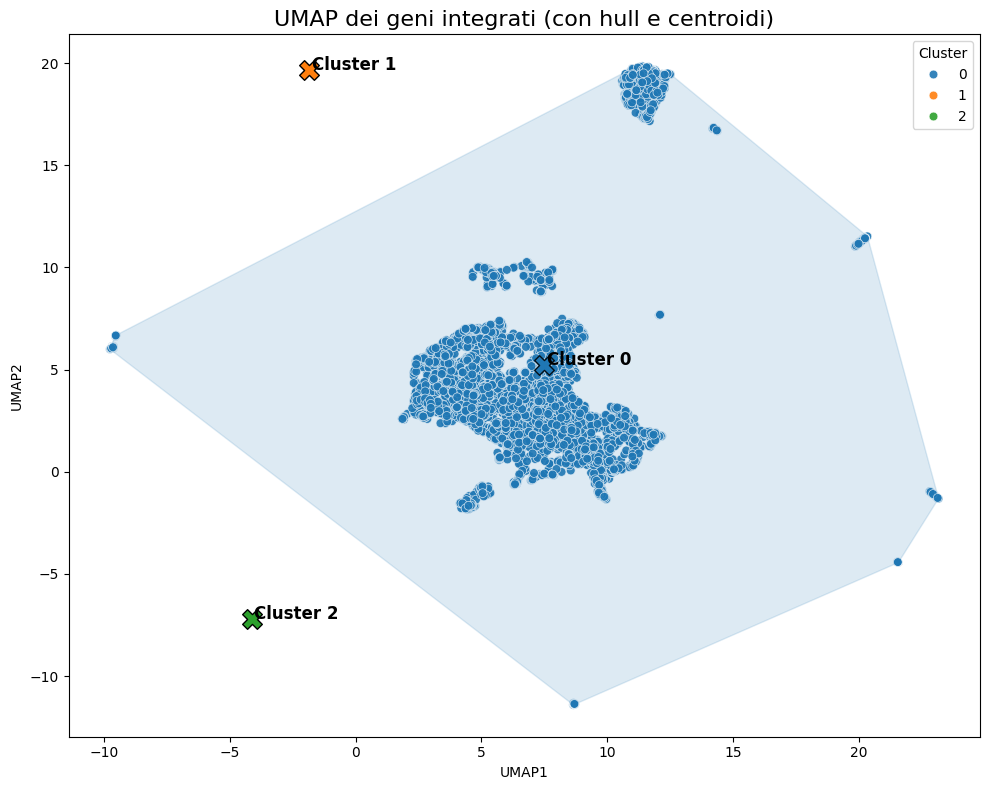

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull

plt.figure(figsize=(10, 8))

# palette cluster
palette = sns.color_palette("tab10", len(UMAP_df["cluster"].unique()))

# plot punti
sns.scatterplot(
    data=UMAP_df,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette=palette,
    s=40,
    alpha=0.9
)

# Convex hull + centroidi
for c in UMAP_df["cluster"].unique():
    subset = UMAP_df[UMAP_df["cluster"] == c][["UMAP1", "UMAP2"]].values
    
    # calcolo centroide
    centroid = subset.mean(axis=0)
    
    # disegno del centroide
    plt.scatter(centroid[0], centroid[1], marker="X", s=200, c=[palette[c]], edgecolor="black")
    plt.text(centroid[0]+0.1, centroid[1], f"Cluster {c}", fontsize=12, weight="bold")
    
    # Convex hull (solo se > 3 punti)
    if subset.shape[0] > 3:
        hull = ConvexHull(subset)
        hull_points = subset[hull.vertices]
        plt.fill(
            hull_points[:,0],
            hull_points[:,1],
            alpha=0.15,
            color=palette[c]
        )

plt.title("UMAP dei geni integrati (con hull e centroidi)", fontsize=16)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


Interpretazione dei cluster (GO & HPO enrichment)

estrazione geni per clusters

In [190]:
clusters = {}
for c in sorted(Z_clean["cluster"].unique()):
    clusters[c] = Z_clean.index[Z_clean["cluster"] == c].tolist()

clusters


{np.int32(0): [10,
  16,
  18,
  19,
  20,
  21,
  22,
  24,
  31,
  34,
  35,
  36,
  37,
  38,
  39,
  49,
  50,
  51,
  54,
  58,
  59,
  60,
  70,
  71,
  72,
  81,
  87,
  88,
  90,
  91,
  93,
  94,
  95,
  100,
  102,
  103,
  104,
  107,
  109,
  111,
  112,
  118,
  120,
  125,
  126,
  128,
  132,
  135,
  150,
  151,
  153,
  155,
  158,
  162,
  164,
  174,
  175,
  176,
  178,
  181,
  182,
  183,
  185,
  189,
  190,
  191,
  196,
  197,
  203,
  204,
  207,
  208,
  210,
  212,
  213,
  215,
  217,
  220,
  224,
  226,
  229,
  238,
  240,
  241,
  242,
  249,
  257,
  258,
  265,
  267,
  268,
  269,
  270,
  271,
  272,
  274,
  275,
  283,
  284,
  285,
  286,
  287,
  288,
  291,
  308,
  311,
  318,
  324,
  326,
  330,
  331,
  335,
  336,
  338,
  344,
  345,
  348,
  351,
  353,
  355,
  356,
  359,
  361,
  362,
  367,
  368,
  372,
  375,
  383,
  387,
  396,
  399,
  401,
  402,
  403,
  407,
  410,
  411,
  412,
  415,
  421,
  427,
  429,
  435,
  439,
  440

Funzione che calcola i GO/HPO caratteristici

In [191]:
def cluster_enrichment(binary_matrix, gene_list, top_k=10):
    """
    binary_matrix: DataFrame (geni × GOterms)
    gene_list: lista dei geni nel cluster
    """
    # subset cluster
    sub = binary_matrix.loc[gene_list]
    
    # frequenza nel cluster
    freq_cluster = sub.mean(axis=0)
    
    # frequenza totale
    freq_total = binary_matrix.mean(axis=0)
    
    # enrichment ratio
    enrichment = (freq_cluster + 1e-6) / (freq_total + 1e-6)
    
    # mettiamo tutto in un dataframe
    df = pd.DataFrame({
        "freq_cluster": freq_cluster,
        "freq_total": freq_total,
        "enrichment": enrichment
    })
    
    return df.sort_values("enrichment", ascending=False).head(top_k)


Calcolo dei GO terms caratteristici per ogni cluster

In [192]:
#Biological Process (BP)
for c in clusters:
    print(f"\n=== Cluster {c} — BP ===")
    print(cluster_enrichment(bp_filtered, clusters[c], top_k=10))


#Cellular Component (CC)
for c in clusters:
    print(f"\n=== Cluster {c} — CC ===")
    print(cluster_enrichment(cc_filtered, clusters[c], top_k=10))

#Molecular Function (MF)
for c in clusters:
    print(f"\n=== Cluster {c} — MF ===")
    print(cluster_enrichment(mf_filtered, clusters[c], top_k=10))



=== Cluster 0 — BP ===
            freq_cluster  freq_total  enrichment
GO.0006629      0.088785    0.087980    1.009151
GO.0030001      0.060358    0.059811    1.009151
GO.0050801      0.051986    0.051515    1.009151
GO.0055080      0.050623    0.050164    1.009151
GO.0006954      0.044782    0.044376    1.009151
GO.0006873      0.042835    0.042446    1.009151
GO.0008610      0.042640    0.042254    1.009151
GO.0030003      0.041667    0.041289    1.009151
GO.0032787      0.040888    0.040517    1.009151
GO.0044782      0.039914    0.039552    1.009151

=== Cluster 1 — BP ===
            freq_cluster  freq_total  enrichment
GO.0042704      0.068966    0.000386  178.264756
GO.1902729      0.034483    0.000193  177.807743
GO.1905006      0.034483    0.000193  177.807743
GO.1905223      0.034483    0.000193  177.807743
GO.0002651      0.034483    0.000193  177.807743
GO.1905317      0.034483    0.000193  177.807743
GO.0035906      0.034483    0.000193  177.807743
GO.0021647      0.034

Costruiamo il grafo dei geni

In [66]:
pip install networkx

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.6 MB 4.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [193]:


import networkx as nx
import numpy as np

# 1) Usiamo solo i geni per cui abbiamo il cluster
genes = Z_clean.index
sim_sub = sim.loc[genes, genes]

# 2) Soglia di similarità per creare gli archi
THRESHOLD = 0.8  # puoi provare 0.6, 0.8, ecc.

G = nx.Graph()

# Aggiungo i nodi con attributo 'cluster'
for gene in genes:
    G.add_node(gene, cluster=int(Z_clean.loc[gene, "cluster"]))

# Aggiungo gli archi per similarità >= soglia
for i, g1 in enumerate(genes):
    for j in range(i+1, len(genes)):
        g2 = genes[j]
        w = sim_sub.loc[g1, g2]
        if w >= THRESHOLD:
            G.add_edge(g1, g2, weight=float(w))

print("Nodi nel grafo:", G.number_of_nodes())
print("Archi nel grafo (sim >= soglia):", G.number_of_edges())



Nodi nel grafo: 5183
Archi nel grafo (sim >= soglia): 124078


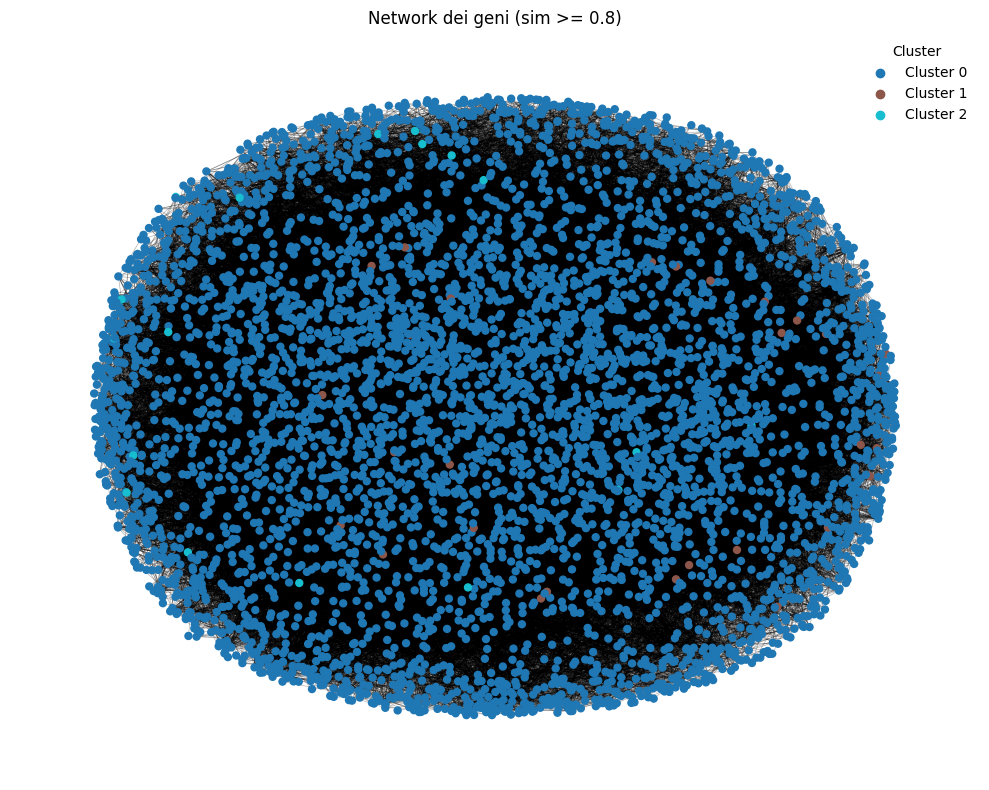

In [194]:
import matplotlib.pyplot as plt

# Layout (può essere un po' lento se ci sono molti nodi)
pos = nx.spring_layout(G, seed=42, k=0.5)  # k controlla la distanza tra i nodi

# Costruisco una lista di colori per nodo in base al cluster
clusters = nx.get_node_attributes(G, "cluster")
unique_clusters = sorted(set(clusters.values()))

# palette semplice
colors_map = plt.cm.get_cmap("tab10", len(unique_clusters))
node_colors = [colors_map(clusters[node]) for node in G.nodes()]

plt.figure(figsize=(10, 8))

# Disegno archi
nx.draw_networkx_edges(
    G, pos,
    alpha=0.3,
    width=0.5
)

# Disegno nodi
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=25
)

# (Opzionale) niente label dei geni, altrimenti è illeggibile

# Legenda per i cluster (costruita a mano)
for c in unique_clusters:
    plt.scatter([], [], color=colors_map(c), label=f"Cluster {c}")
plt.legend(scatterpoints=1, frameon=False, title="Cluster")

plt.title(f"Network dei geni (sim >= {THRESHOLD})")
plt.axis("off")
plt.tight_layout()
plt.show()


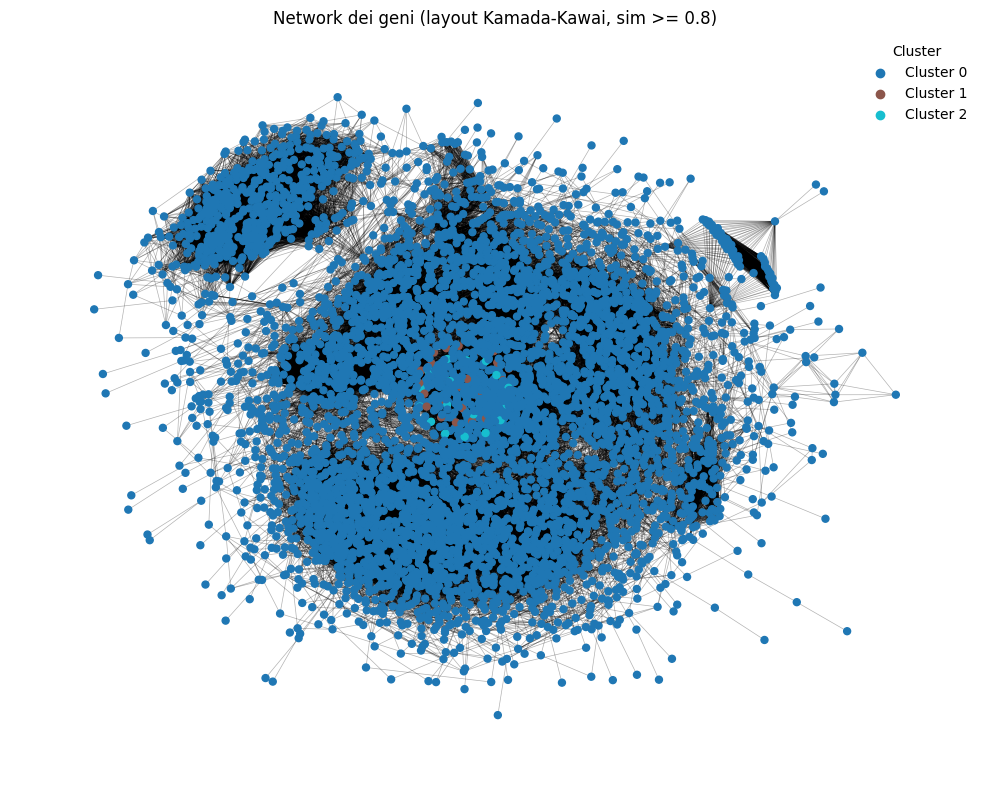

In [195]:
import matplotlib.pyplot as plt

# Layout Kamada-Kawai (più ordinato, edge-length più uniforme)
pos = nx.kamada_kawai_layout(G)

# Costruisco colori per cluster
clusters = nx.get_node_attributes(G, "cluster")
unique_clusters = sorted(set(clusters.values()))
colors_map = plt.cm.get_cmap("tab10", len(unique_clusters))
node_colors = [colors_map(clusters[node]) for node in G.nodes()]

plt.figure(figsize=(10, 8))

# Disegno archi
nx.draw_networkx_edges(
    G, pos,
    alpha=0.3,
    width=0.5
)

# Disegno nodi
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=25
)

# Legenda
for c in unique_clusters:
    plt.scatter([], [], color=colors_map(c), label=f"Cluster {c}")

plt.legend(scatterpoints=1, frameon=False, title="Cluster")
plt.title(f"Network dei geni (layout Kamada-Kawai, sim >= {THRESHOLD})")
plt.axis("off")
plt.tight_layout()
plt.show()


Grafo dei cluster (super compatto)

versione 2

In [197]:
THRESHOLD = 0.9  # puoi alzarlo/lowerarlo

G_full = nx.Graph()
genes = Z_clean.index
sim_sub = sim.loc[genes, genes]

# nodi
for gene in genes:
    G_full.add_node(gene, cluster=int(Z_clean.loc[gene, "cluster"]))

# archi
for i, g1 in enumerate(genes):
    for j in range(i+1, len(genes)):
        g2 = genes[j]
        w = sim_sub.loc[g1, g2]
        if w >= THRESHOLD:
            G_full.add_edge(g1, g2, weight=float(w))


Nodi nel grafo ridotto: 97
Archi nel grafo ridotto: 988


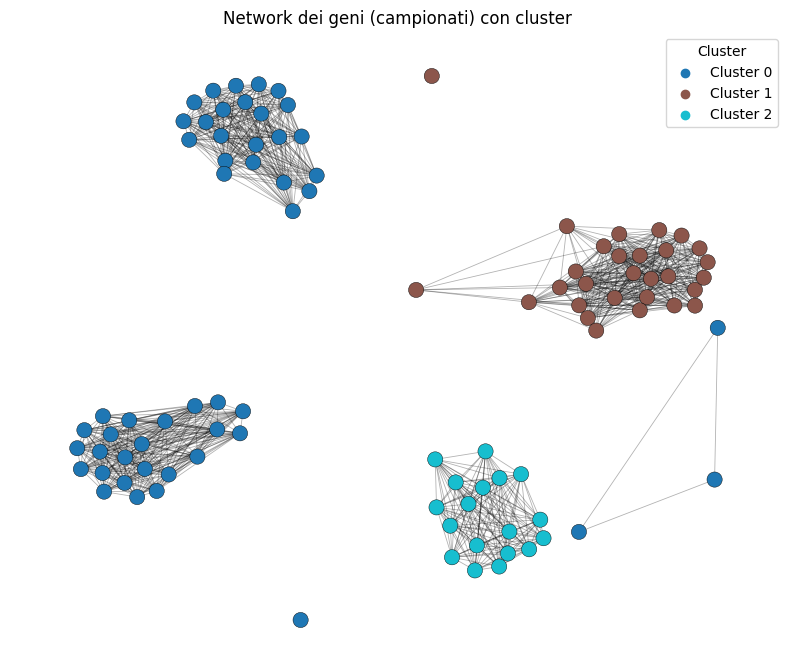

In [200]:
N_GENES_PER_CLUSTER = 50

selected_genes = []

for c in sorted(Z_clean["cluster"].unique()):
    nodes_c = [n for n in G_full.nodes() if G_full.nodes[n]["cluster"] == c]
    
    # degree centrality
    degrees = {n: G_full.degree(n) for n in nodes_c}
    
    # prendi i top N
    top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:N_GENES_PER_CLUSTER]
    
    selected_genes.extend(top_nodes)

len(selected_genes)


G_small = G_full.subgraph(selected_genes).copy()
print("Nodi nel grafo ridotto:", G_small.number_of_nodes())
print("Archi nel grafo ridotto:", G_small.number_of_edges())



plt.figure(figsize=(10,8))

pos = nx.spring_layout(G_small, seed=42, k=0.6)

clusters = nx.get_node_attributes(G_small, "cluster")
unique_clusters = sorted(set(clusters.values()))
palette = plt.cm.get_cmap("tab10", len(unique_clusters))

node_colors = [palette(clusters[n]) for n in G_small.nodes()]

# edges
nx.draw_networkx_edges(G_small, pos, alpha=0.3, width=0.6)

# nodes
nx.draw_networkx_nodes(
    G_small, pos,
    node_color=node_colors,
    node_size=120,
    edgecolors="black",
    linewidths=0.3
)

# labels facoltativi
# nx.draw_networkx_labels(G_small, pos, font_size=6)

# legenda
for c in unique_clusters:
    plt.scatter([], [], color=palette(c), label=f"Cluster {c}")
plt.legend(title="Cluster")

plt.title("Network dei geni (campionati) con cluster")
plt.axis("off")
plt.show()



K-MEANS

In [201]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(Z_scaled)

# aggiungiamo i cluster K-means a Z_clean
Z_clean["kmeans_cluster"] = kmeans_labels

# distribuzione
unique, counts = np.unique(kmeans_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"K-Means cluster {c}: {n} geni")


K-Means cluster 0: 4570 geni
K-Means cluster 1: 29 geni
K-Means cluster 2: 584 geni


visualizzazione umap con k-means

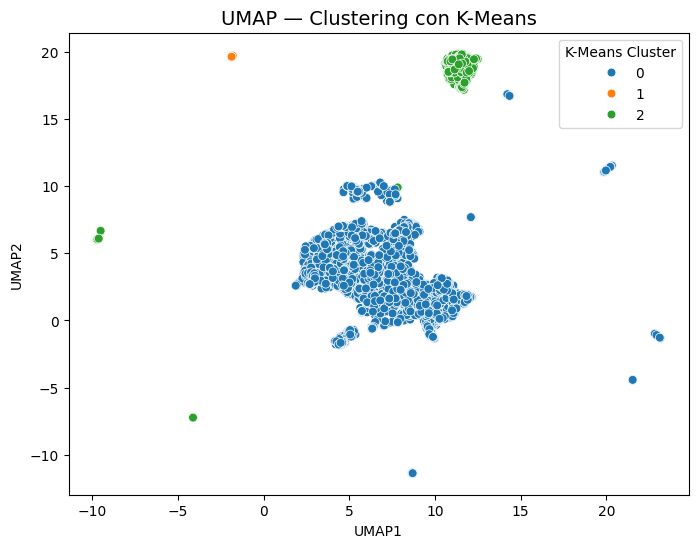

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns

UMAP_df["kmeans_cluster"] = Z_clean["kmeans_cluster"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=UMAP_df,
    x="UMAP1", y="UMAP2",
    hue="kmeans_cluster",
    palette="tab10",
    s=40
)

plt.title("UMAP — Clustering con K-Means", fontsize=14)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="K-Means Cluster")
plt.show()


🔵 3) Heatmap di similarità ordinata per cluster K-Means

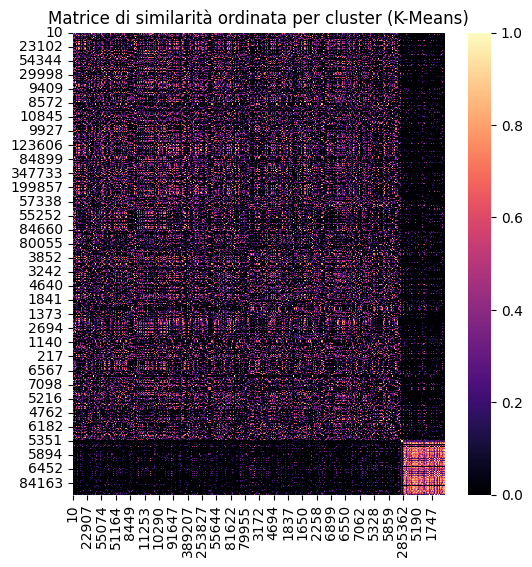

In [204]:
# restrizione ai geni usati
sim_k = sim.loc[Z_clean.index, Z_clean.index]

# ordinamento per cluster K-Means
order_k = np.argsort(Z_clean["kmeans_cluster"].values)
genes_ordered_k = sim_k.index[order_k]

sim_ordered_k = sim_k.loc[genes_ordered_k, genes_ordered_k]

plt.figure(figsize=(6,6))
sns.heatmap(sim_ordered_k, cmap="magma", vmin=0, vmax=1)
plt.title("Matrice di similarità ordinata per cluster (K-Means)")
plt.show()


Confronto diretto: Spectral vs K-Means

In [205]:
comparison_df = Z_clean[["cluster", "kmeans_cluster"]].copy()
comparison_df


,cluster,kmeans_cluster
10,0,0
16,0,0
18,0,0
19,0,0
20,0,0
...,...,...
105371045,0,0
105804841,0,0
109580095,0,0
111365204,0,0


In [206]:
pd.crosstab(
    comparison_df["cluster"],
    comparison_df["kmeans_cluster"],
    rownames=["Spectral"], 
    colnames=["K-Means"]
)


K-Means,0,1,2
Spectral,,,
0,4570,0,566
1,0,29,0
2,0,0,18


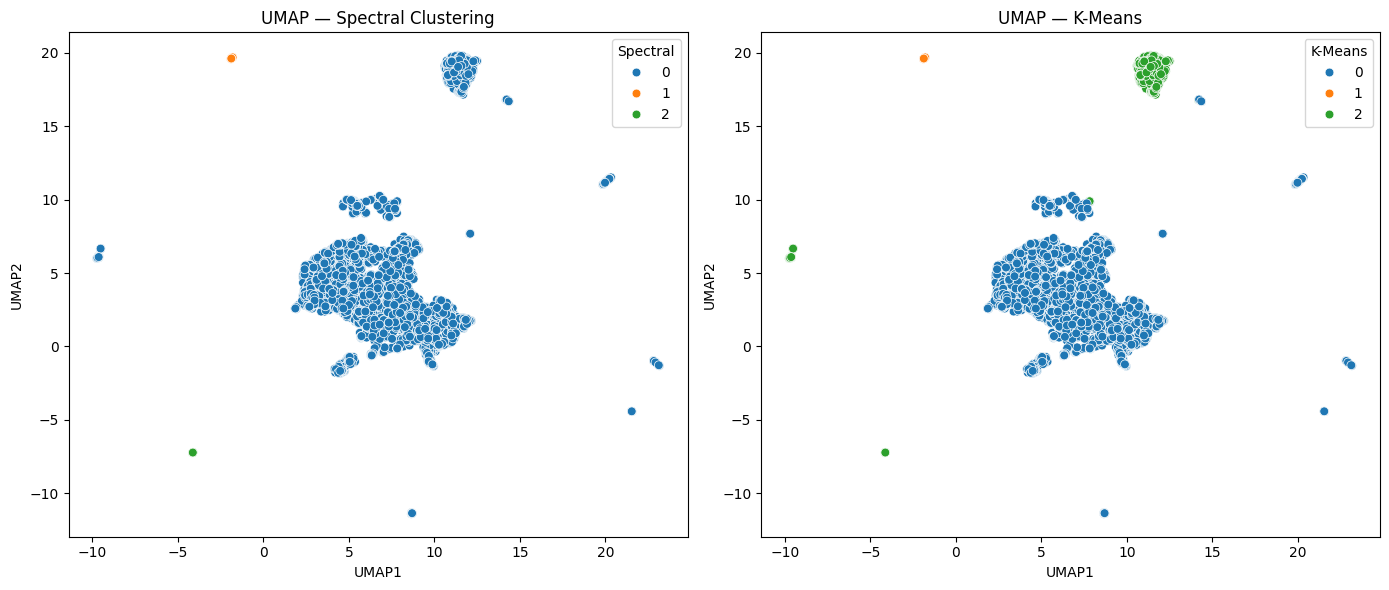

In [207]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Spectral
sns.scatterplot(
    ax=axes[0],
    data=UMAP_df,
    x="UMAP1", y="UMAP2",
    hue="cluster", palette="tab10",
    s=40
)
axes[0].set_title("UMAP — Spectral Clustering")
axes[0].legend(title="Spectral", bbox_to_anchor=(1,1))

# K-Means
sns.scatterplot(
    ax=axes[1],
    data=UMAP_df,
    x="UMAP1", y="UMAP2",
    hue="kmeans_cluster", palette="tab10",
    s=40
)
axes[1].set_title("UMAP — K-Means")
axes[1].legend(title="K-Means", bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()


LOGISTIC REGRESSION

In [208]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

# =======================
# DATA
# =======================

X = Z_scaled                     # fattori MOFA scaled
y = Z_clean["kmeans_cluster"].values    # target = cluster spectral

# =======================
# MODELLO LOGISTIC REGRESSION
# =======================

log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=500,
    random_state=42
)

log_reg.fit(X, y)

# =======================
# ACCURACY
# =======================
pred = log_reg.predict(X)
acc = accuracy_score(y, pred)

print(f"Accuracy Logistic Regression: {acc:.4f}\n")
print(classification_report(y, pred))


Accuracy Logistic Regression: 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4570
           1       1.00      1.00      1.00        29
           2       1.00      1.00      1.00       584

    accuracy                           1.00      5183
   macro avg       1.00      1.00      1.00      5183
weighted avg       1.00      1.00      1.00      5183



Importanza dei fattori MOFA

In [209]:
coeffs = pd.DataFrame(
    log_reg.coef_,
    columns=[f"Factor_{i+1}" for i in range(X.shape[1])],
    index=[f"Cluster_{c}" for c in sorted(np.unique(y))]
)

coeffs


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,Factor_11,Factor_12,Factor_13,Factor_14,Factor_15
Cluster_0,-1.256348,1.847084,0.036891,-0.043927,-0.020042,-0.011825,-0.176347,-0.016828,-0.458211,0.105736,0.026140,-0.015830,0.008010,-0.039770,-0.720407
Cluster_1,-0.045244,-0.039467,-0.025993,-0.000867,0.027028,0.000481,0.793528,-0.041222,-0.027757,0.018837,0.016109,-0.015205,0.000585,0.002951,-0.052619
Cluster_2,1.301593,-1.807618,-0.010899,0.044794,-0.006985,0.011344,-0.617181,0.058050,0.485969,-0.124573,-0.042249,0.031035,-0.008595,0.036820,0.773026


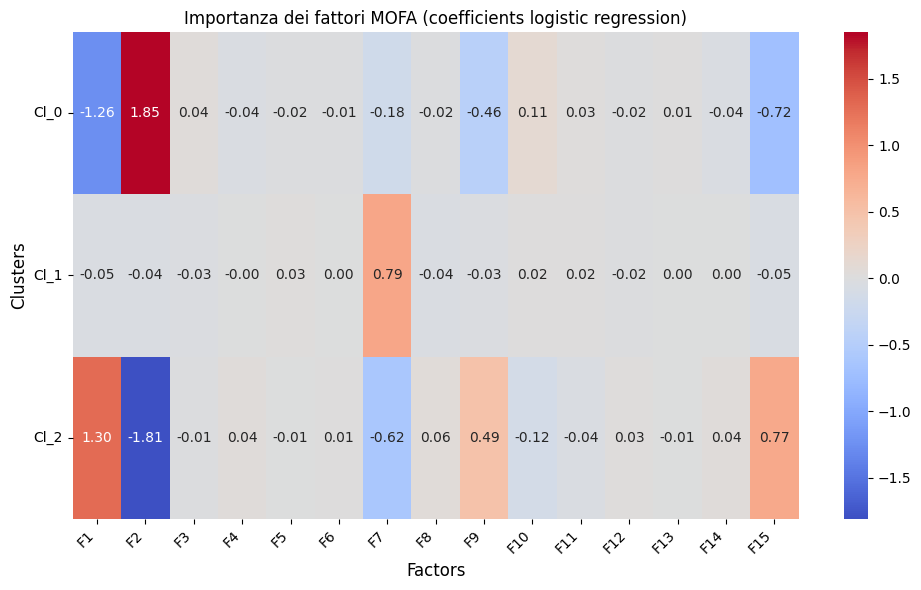

In [210]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# sns.heatmap(coeffs, cmap="coolwarm", center=0, annot=True, fmt=".2f")
# plt.title("Importanza dei fattori MOFA (coefficients logistic regression)")
# plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ax = sns.heatmap(
    coeffs,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

# Titolo
plt.title("Importanza dei fattori MOFA (coefficients logistic regression)")

# Etichette assi
ax.set_xlabel("Factors", fontsize=12)
ax.set_ylabel("Clusters", fontsize=12)

# Se vuoi numerare i factors in stile Factor_1, Factor_2, ...
ax.set_xticklabels(
    [f"F{i+1}" for i in range(len(coeffs.columns))],
    rotation=45,
    ha="right"
)

# Numerazione dei clusters (Cluster_0, Cluster_1, ...)
ax.set_yticklabels(
    [f"Cl_{i}" for i in range(len(coeffs.index))],
    rotation=0
)

plt.tight_layout()
plt.show()


In [211]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# plt.figure(figsize=(10,6))

# # Soglia sotto la quale NON mostriamo l'annotazione
# THRESH = 0.05

# # Prepariamo la matrice delle annotazioni
# annot_matrix = coeffs.copy().astype(str)

# for r in range(coeffs.shape[0]):
#     for c in range(coeffs.shape[1]):
#         if abs(coeffs.iloc[r,c]) < THRESH:
#             annot_matrix.iloc[r,c] = ""  # lascia vuoto
#         else:
#             annot_matrix.iloc[r,c] = f"{coeffs.iloc[r,c]:.2f}"

# # Heatmap con annotazioni filtrate
# ax = sns.heatmap(
#     coeffs,
#     cmap="coolwarm",
#     center=0,
#     annot=annot_matrix,
#     fmt="",
#     cbar=True
# )

# plt.title("Importanza dei fattori MOFA (coefficients logistic regression)")
# ax.set_xlabel("Factors", fontsize=12)
# ax.set_ylabel("Clusters", fontsize=12)

# ax.set_xticklabels(
#     [f"F{i+1}" for i in range(len(coeffs.columns))],
#     rotation=45,
#     ha="right"
# )

# ax.set_yticklabels(
#     [f"Cl_{i}" for i in range(len(coeffs.index))],
#     rotation=0
# )

# plt.tight_layout()
# plt.show()


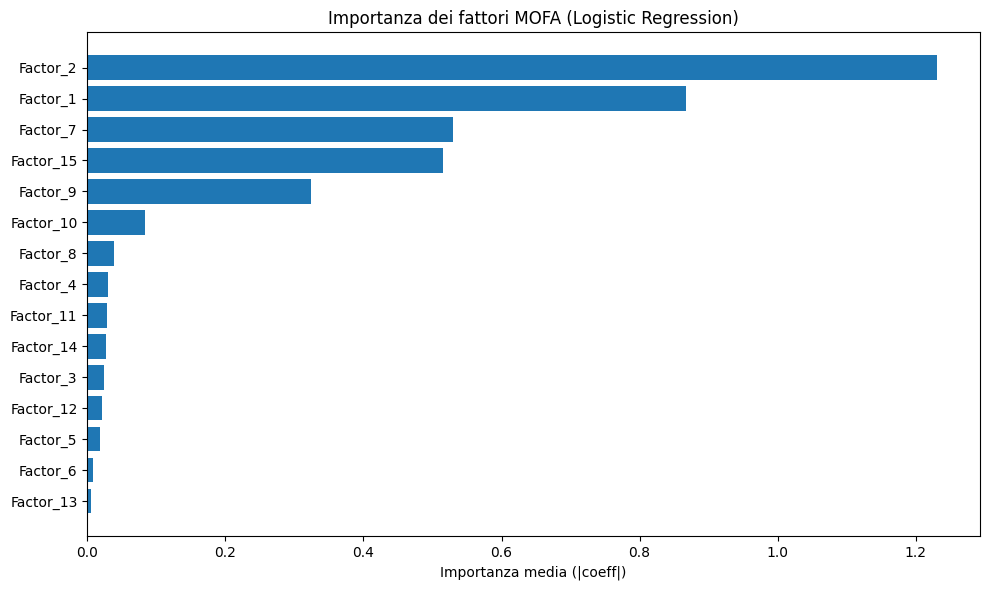

In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importanza media assoluta dei coefficienti
importance = coeffs.abs().mean(axis=0)

# ordina dal più importante al meno
importance_sorted = importance.sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.barh(importance_sorted.index, importance_sorted.values)
plt.xlabel("Importanza media (|coeff|)")
plt.title("Importanza dei fattori MOFA (Logistic Regression)")
plt.tight_layout()
plt.show()


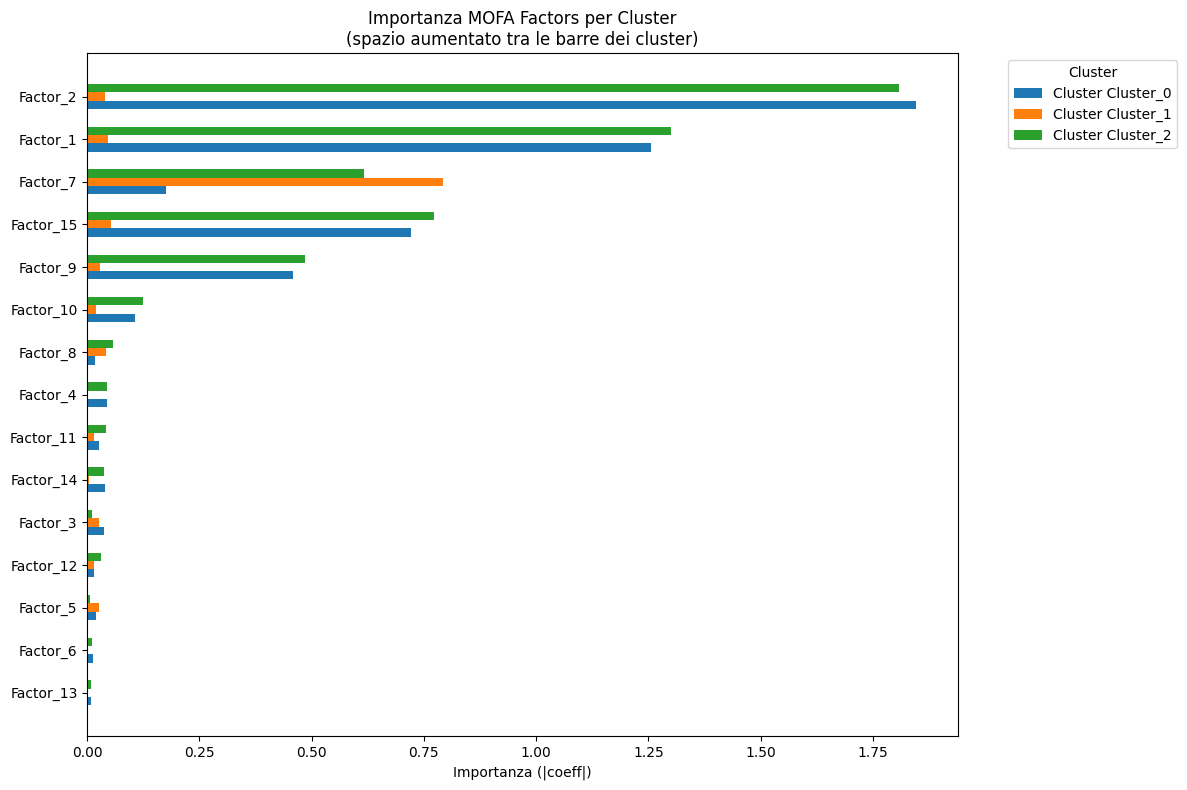

In [214]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Importanza globale media
# ----------------------------
importance = coeffs.abs().mean(axis=0)

# Ordine globale (dal meno al più importante)
order = importance.sort_values(ascending=True).index

# Riordina i coeffs usando l'ordine globale
coeffs_sorted = coeffs[order].abs()

# ----------------------------
# 2. Parametri grafici
# ----------------------------
bar_height = 0.35        # barra più sottile
cluster_offset = 0.35     # distanza tra cluster sullo stesso factor
factor_spacing = 1.8      # distanza tra un factor e l'altro

clusters = coeffs_sorted.index
n_clusters = len(clusters)
n_factors = len(order)

# coordinate Y per i fattori (spaziati)
base_y = np.arange(n_factors) * factor_spacing

plt.figure(figsize=(12, 8))

for i, cluster in enumerate(clusters):
    plt.barh(
        y=base_y + i * cluster_offset,     # qui aumentiamo lo spazio tra cluster
        width=coeffs_sorted.loc[cluster],
        height=bar_height,
        label=f"Cluster {cluster}"
    )

plt.yticks(base_y + cluster_offset, order)

plt.xlabel("Importanza (|coeff|)")
plt.title("Importanza MOFA Factors per Cluster\n(spazio aumentato tra le barre dei cluster)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


prova vis 3d 

In [215]:
import numpy as np
import pandas as pd

# importanza globale media (assoluta) per fattore
importance = coeffs.abs().mean(axis=0)

# prendi i 3 fattori più importanti
top3 = importance.sort_values(ascending=False).index[:3]
print("Top 3 factors:", top3.tolist())


Top 3 factors: ['Factor_2', 'Factor_1', 'Factor_7']


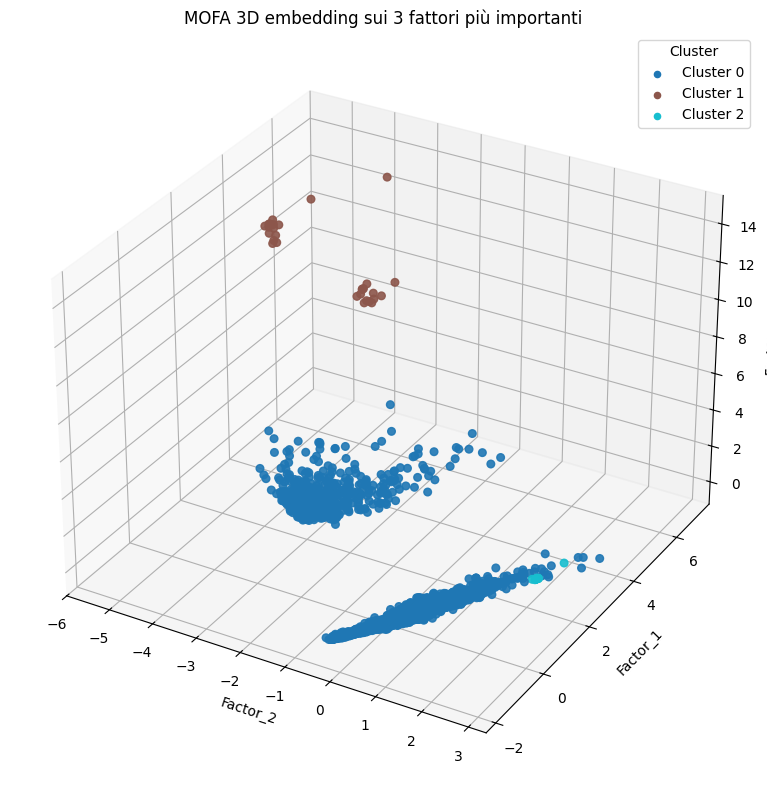

In [217]:
# estrai i 3 fattori più importanti
f1, f2, f3 = top3

X3d = Z_clean[[f1, f2, f3]].values
labels = Z_clean["cluster"].values

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessario per 3D

# palette colori per i cluster
unique_clusters = np.sort(np.unique(labels))
colors_map = plt.cm.get_cmap("tab10", len(unique_clusters))
cluster_colors = [colors_map(c) for c in labels]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X3d[:, 0], X3d[:, 1], X3d[:, 2],
    c=cluster_colors,
    s=30,
    alpha=0.9
)

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_zlabel(f3)
ax.set_title("MOFA 3D embedding sui 3 fattori più importanti")

# legenda manuale
for c in unique_clusters:
    ax.scatter([], [], [], c=colors_map(c), label=f"Cluster {c}")
ax.legend(title="Cluster")

plt.tight_layout()
plt.show()


In [123]:
pip install plotly


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.9 MB 11.5 MB/s eta 0:00:01
     |████████████████████████████████| 425 kB 17.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [125]:
pip install --upgrade nbformat


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 78 kB 5.5 MB/s eta 0:00:011
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [133]:
pipx install xyz

SyntaxError: invalid syntax (4076179098.py, line 1)

In [131]:
!pip install ipywidgets



error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

In [218]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"


# Costruiamo un DataFrame con solo i fattori che ci servono + cluster
plot_df = Z_clean[[f1, f2, f3, "kmeans_cluster"]].copy()
plot_df["gene"] = plot_df.index  # per mostrare il nome del gene in hover

fig = px.scatter_3d(
    plot_df,
    x=f1,
    y=f2,
    z=f3,
    color="kmeans_cluster",
    hover_name="gene",
    title=f"Embedding 3D MOFA sui 3 fattori più importanti ({f1}, {f2}, {f3})"
)

# Un po' di styling
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_layout(
    legend_title_text="Cluster",
    scene=dict(
        xaxis_title=f1,
        yaxis_title=f2,
        zaxis_title=f3
    )
)

fig.show()


In [136]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

# cast del cluster a stringa per avere categorie
plot_df = Z_clean[[f1, f2, f3, "kmeans_cluster"]].copy()
plot_df["cluster_str"] = plot_df["kmeans_cluster"].astype(str)
plot_df["gene"] = plot_df.index  # per hover

fig = px.scatter_3d(
    plot_df,
    x=f1,
    y=f2,
    z=f3,
    color="cluster_str",
    hover_name="gene",
    title=f"Embedding 3D MOFA sui 3 fattori più importanti ({f1}, {f2}, {f3})",
    color_discrete_sequence=["#1f77b4", "#ff7f0e", "#2ca02c"]  # blu, arancione, verde
)

fig.update_traces(marker=dict(size=4, opacity=0.8))

fig.update_layout(
    legend_title_text="Cluster",
    scene=dict(
        xaxis_title=f1,
        yaxis_title=f2,
        zaxis_title=f3
    )
)

fig.show()


Boxplot dei fattori MOFA per cluster

Top 5 factors: ['Factor_2', 'Factor_1', 'Factor_7', 'Factor_15', 'Factor_9']


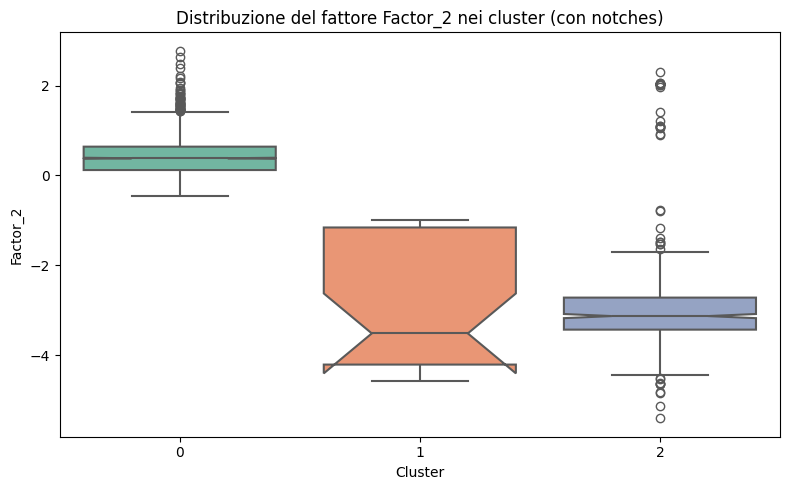

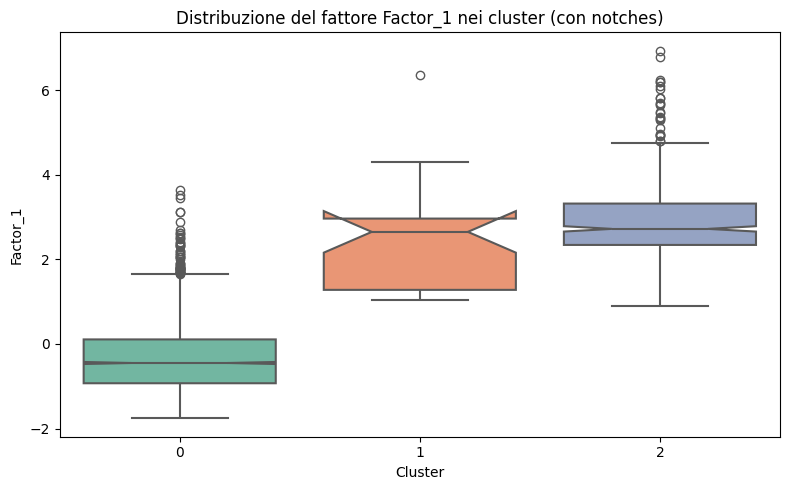

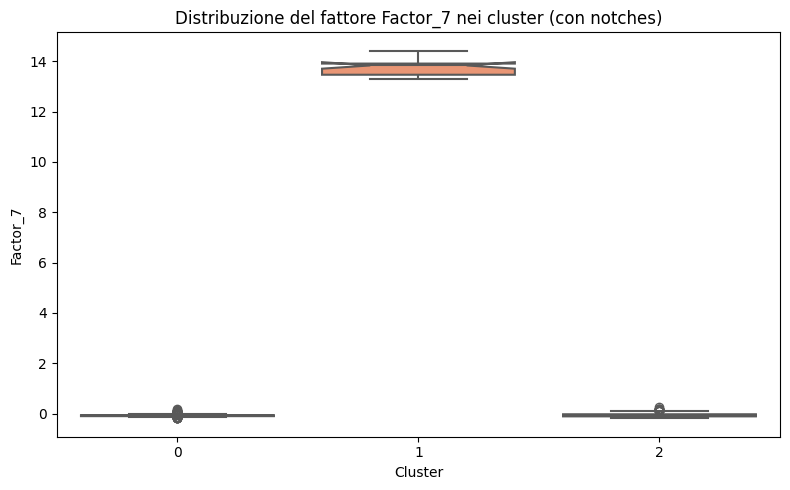

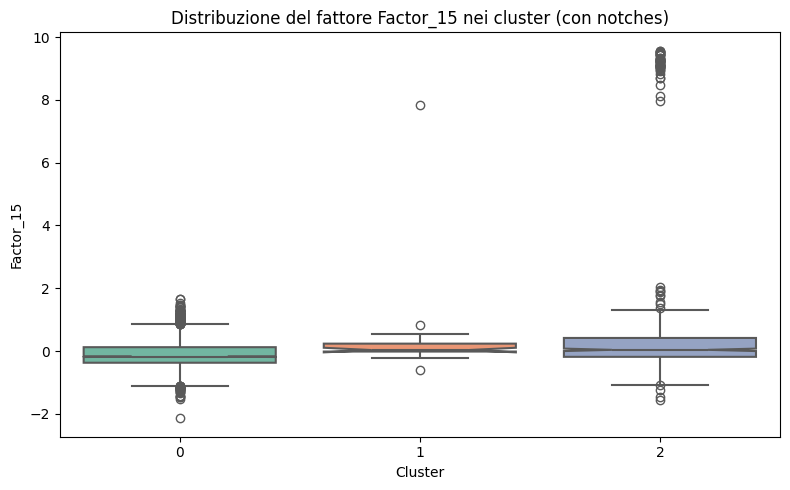

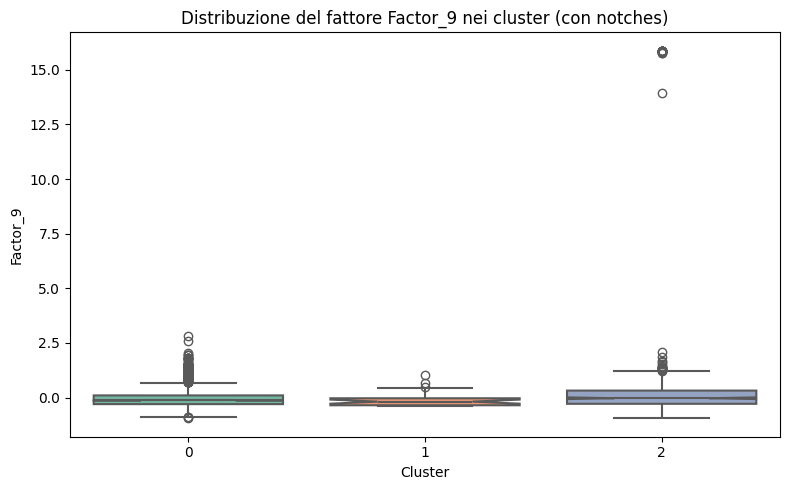

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------
# Step 1: Identificare i 5 fattori più importanti
# ---------------------------------------

importance = coeffs.abs().mean(axis=0)
top5 = importance.sort_values(ascending=False).index[:5]
print("Top 5 factors:", top5.tolist())

# ---------------------------------------
# Step 2: Preparo dataframe con solo i fattori top 5
# ---------------------------------------

df_box = Z_clean.copy()
df_box["cluster"] = df_box["kmeans_cluster"].astype(str)

# ---------------------------------------
# Step 3: Un grafico con NOTCH per ogni fattore
# ---------------------------------------

for factor in top5:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df_box,
        x="cluster",
        y=factor,
        palette="Set2",
        notch=True,   # ❤️ notch attivato
        linewidth=1.5
    )
    
    plt.title(f"Distribuzione del fattore {factor} nei cluster (con notches)")
    plt.xlabel("Cluster")
    plt.ylabel(factor)
    plt.tight_layout()
    plt.show()
